<h1 align="center" id="top"><u>Pokemon classification</u></h1>
<h3 align="center"><u>Clément MOLLY-MITTON | Diane VERBECQ</u></h3>

# Table of Contents
***
1. [Import](#import)

## Import
***

In [1]:
from pathlib import Path

from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

from background import remove_background
from config import BackgroundMethod, ExtractMethod
from display import show_confusion_matrix, show_image
from pipeline import evaluate_all_methods, split_dataset
from preprocessing import preprocessing
from utils import build_dataframe, load_image

Let's now load the dataset using pandas (mapping the images path with their respective pokemon)

In [2]:
data_dir = Path.cwd().resolve().parents[0] / "data" / "fanart-dataset"

fanart_df = build_dataframe(data_dir)

print("\nTotal images:", len(fanart_df))
print("Total Pokémon:", fanart_df["pokemon"].nunique())
print("\n20 most present pokemon:")
print(fanart_df["pokemon"].value_counts().head(20))


Total images: 10710
Total Pokémon: 887

20 most present pokemon:
pokemon
gengar       84
greninja     67
umbreon      67
suicune      65
bulbasaur    64
leafeon      63
sylveon      63
eevee        62
rayquaza     62
garchomp     61
arcanine     60
lugia        60
vaporeon     59
sceptile     58
blastoise    57
scizor       57
zoroark      57
giratina     55
gardevoir    54
mewtwo       54
Name: count, dtype: int64


Now let's filter a bit our dataset so that we only keep pokemons with a sufficient number of images

In [3]:
MIN_PER_CLASS = 15
counts = fanart_df["pokemon"].value_counts()
keep = counts[counts >= MIN_PER_CLASS].index
fanart_df_filtered = fanart_df[fanart_df["pokemon"].isin(keep)].reset_index(drop=True)

print("After filter:")
print("Total images:", len(fanart_df_filtered))
print("Total Pokémon:", fanart_df_filtered["pokemon"].nunique())
print(fanart_df_filtered["pokemon"].value_counts().head(10))

After filter:
Total images: 6957
Total Pokémon: 230
pokemon
gengar       84
greninja     67
umbreon      67
suicune      65
bulbasaur    64
leafeon      63
sylveon      63
eevee        62
rayquaza     62
garchomp     61
Name: count, dtype: int64


In [4]:
fanart_df_filtered

,path,pokemon
0,C:\Users\cleme\Documents\CentraleSupélec\Cours...,absol
1,C:\Users\cleme\Documents\CentraleSupélec\Cours...,absol
2,C:\Users\cleme\Documents\CentraleSupélec\Cours...,absol
3,C:\Users\cleme\Documents\CentraleSupélec\Cours...,absol
4,C:\Users\cleme\Documents\CentraleSupélec\Cours...,absol
...,...,...
6952,C:\Users\cleme\Documents\CentraleSupélec\Cours...,zorua
6953,C:\Users\cleme\Documents\CentraleSupélec\Cours...,zorua
6954,C:\Users\cleme\Documents\CentraleSupélec\Cours...,zorua
6955,C:\Users\cleme\Documents\CentraleSupélec\Cours...,zorua


Let's encode now the label using sklearn's LabelEncoder and split the dataframe into a dataset of path and labels

In [5]:
top10 = fanart_df_filtered["pokemon"].value_counts().head(10).index
fanart_df_filtered = (
    fanart_df_filtered[fanart_df_filtered["pokemon"].isin(top10)].copy().reset_index(drop=True)
)
print(fanart_df_filtered["pokemon"].value_counts())

pokemon
gengar       84
greninja     67
umbreon      67
suicune      65
bulbasaur    64
leafeon      63
sylveon      63
eevee        62
rayquaza     62
garchomp     61
Name: count, dtype: int64


In [6]:
dataset = fanart_df_filtered["path"]
label = fanart_df_filtered["pokemon"]

label_encoder = LabelEncoder()
label = label_encoder.fit_transform(label)

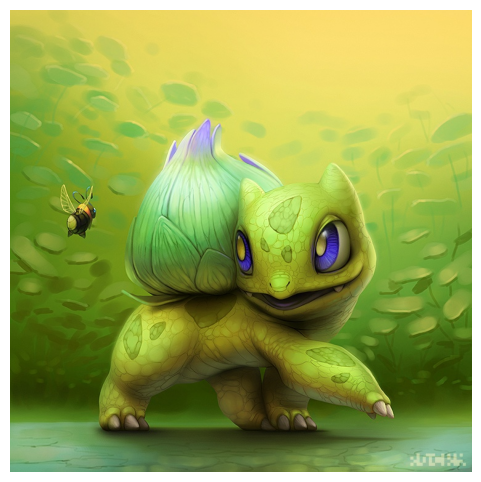

In [7]:
im = load_image(Path(dataset[3]))
show_image(im)

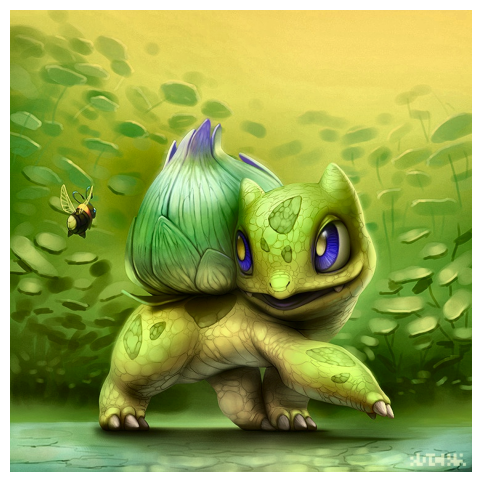

In [8]:
new_im = preprocessing(im)
show_image(new_im)

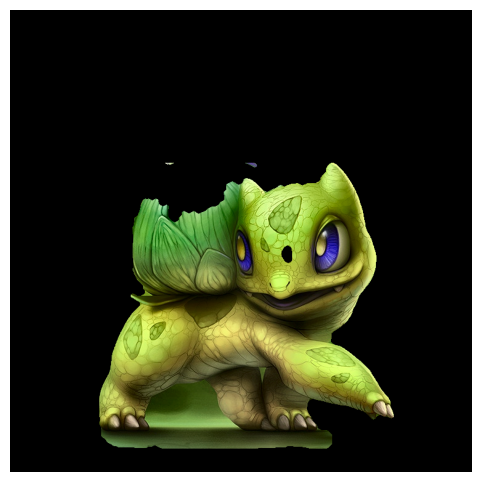

In [9]:
only_pokemon = remove_background(new_im, method=BackgroundMethod.GRABCUT)
show_image(only_pokemon)

In [ ]:
X_train, X_test, y_train, y_test = split_dataset(
    dataset,
    label,
    ExtractMethod.SIFT,
    BackgroundMethod.NONE,
)

[INFO] : Dataset split done ! (train=526, test=132)
Extracting descriptors for train:  10%|█▉                  | 52/526 

In [ ]:
clf = LinearSVC(C=1.0, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

              precision    recall  f1-score   support

   bulbasaur       0.62      0.38      0.48        13
       eevee       0.55      0.50      0.52        12
    garchomp       0.27      0.25      0.26        12
      gengar       0.48      0.65      0.55        17
    greninja       0.69      0.69      0.69        13
     leafeon       0.33      0.38      0.36        13
    rayquaza       0.50      0.58      0.54        12
     suicune       0.78      0.54      0.64        13
     sylveon       0.56      0.69      0.62        13
     umbreon       0.50      0.43      0.46        14

    accuracy                           0.52       132
   macro avg       0.53      0.51      0.51       132
weighted avg       0.53      0.52      0.51       132



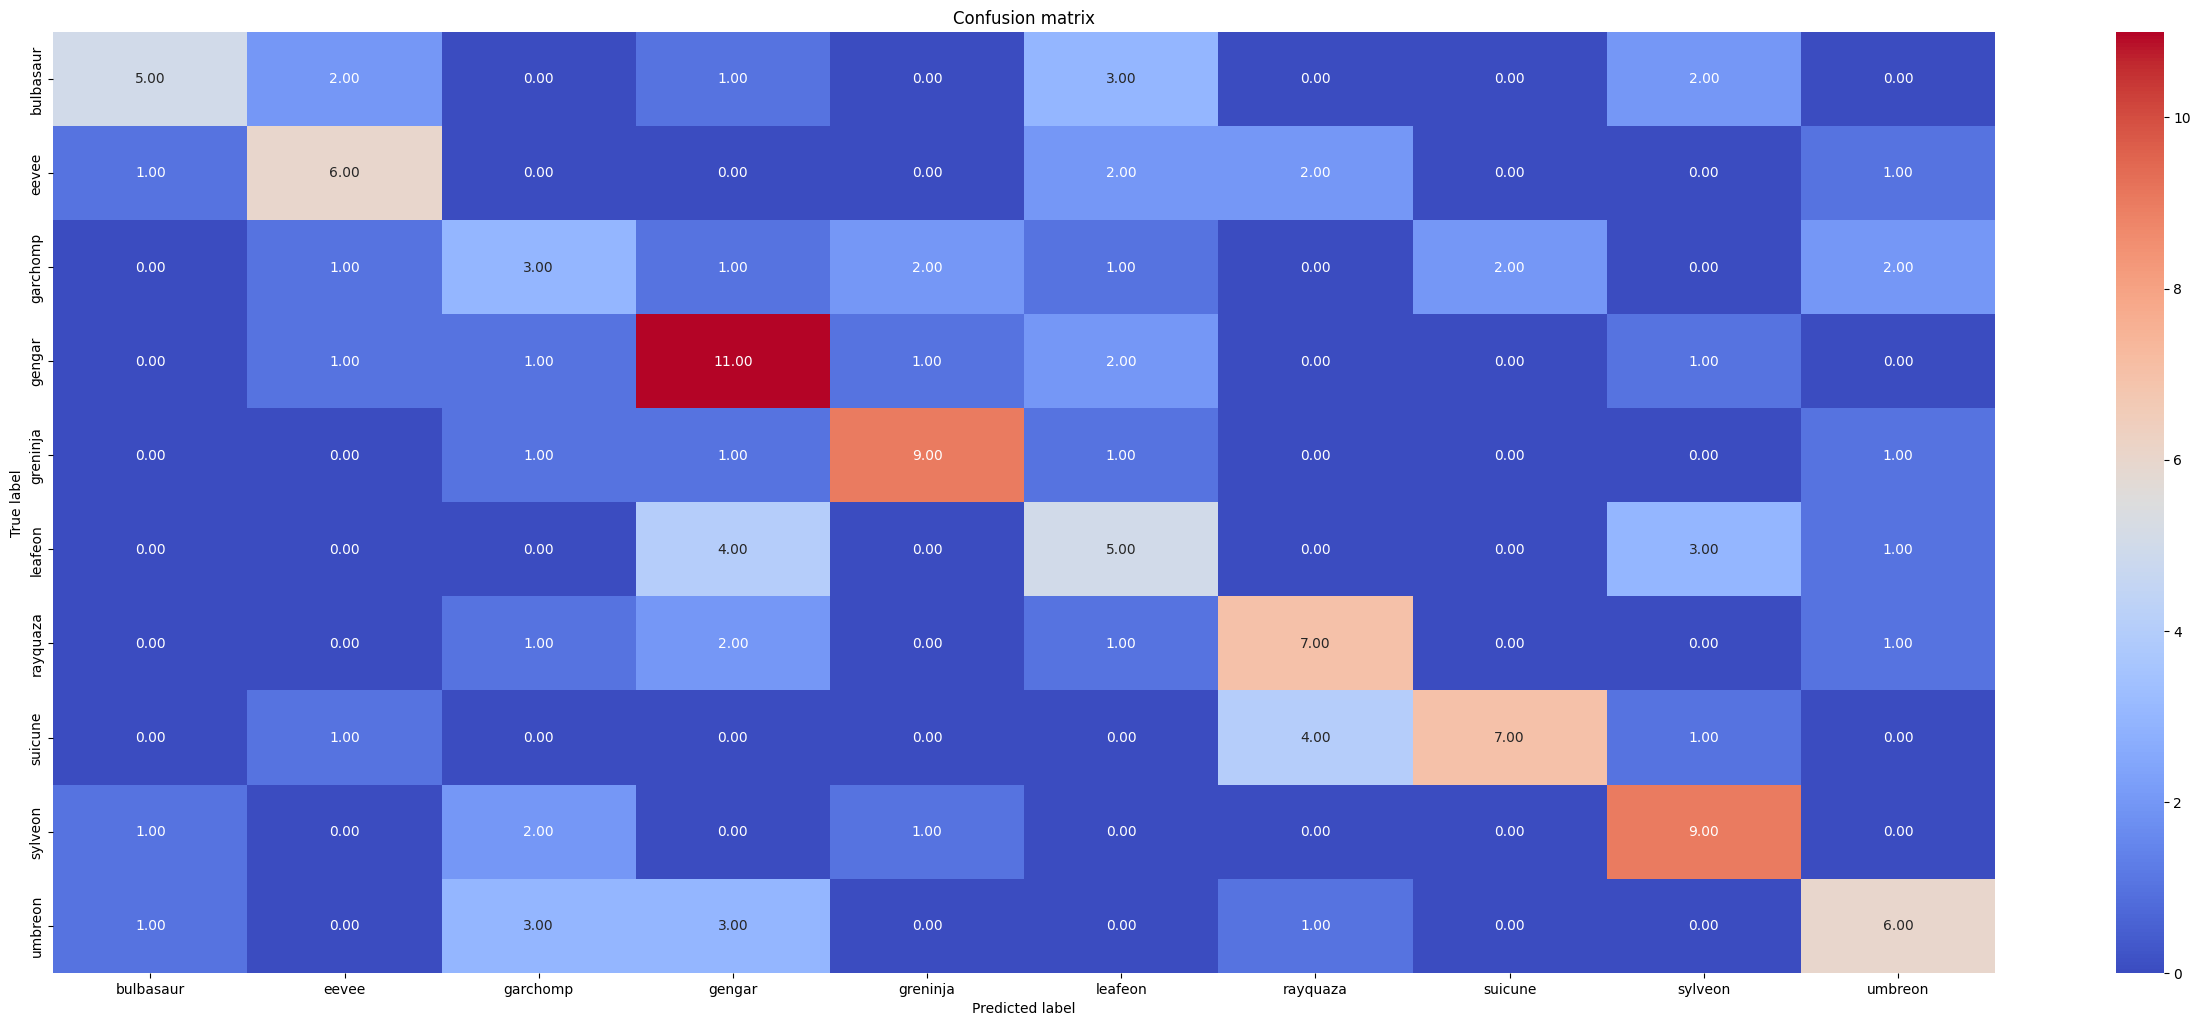

In [ ]:
show_confusion_matrix(y_test, y_pred, label_encoder.classes_, "Confusion matrix")

Now let's test each possibility and compare the results

In [11]:
models = [
    (LinearSVC, {"C": 1.0, "random_state": 42}),
]
results = evaluate_all_methods(dataset, label, label_encoder, models)
results

Evaluation:   0%|                              | 0/1 

Extracting descriptors for train:   0%|                    | 0/526 

Extracting descriptors for test:   0%|                    | 0/132 

,model,extract_method,background_method,accuracy,precision_macro,recall_macro,f1_macro,classification_report,train_time_sec
0,LinearSVC,SIFT,NONE,0.515152,0.528736,0.510127,0.51153,precision recall f1-score ...,0.070288
